**Part (a): Problem formulation**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

plt.rcParams.update({'font.size': 12, 'axes.titlesize': 13})

In [2]:
r         = 6.0
phi       = np.pi / 2
m0        = 1.20
rho       = 1.225e-9
rho_mat   = 0.0027
E         = 69000.0
P0        = 100.0
eta       = 0.70
g         = 9.81
sigma_y   = 90.0
delta_max = 0.5
k         = 2.00


def thrust(R, power=P0):
    return (eta * power * np.sqrt(2000 * rho * np.pi) * R) ** (2 / 3)


def arm_mass(L):
    return 4 * rho_mat * np.pi * r ** 2 * L


def total_mass(L):
    return m0 + arm_mass(L) / 1000


def sigma_max(R, L, power=P0):
    return 4 * thrust(R, power) * L / (np.pi * r ** 3)


def delta_tip(R, L, power=P0):
    return 4 * thrust(R, power) * L ** 3 / (3 * E * np.pi * r ** 4)

In [3]:
def objective(x):
    return arm_mass(x[1])


def constraint_stress(x, power=P0, margin=k):
    return sigma_y - sigma_max(x[0], x[1], power)


def constraint_deflection(x, power=P0, margin=k):
    return delta_max - delta_tip(x[0], x[1], power)


def constraint_thrust(x, power=P0, margin=k):
    return 4 * thrust(x[0], power) - margin * total_mass(x[1]) * g


def constraint_clearance(x, power=P0, margin=k):
    return x[1] * np.sin(phi / 2) - x[0]


x0 = [130.0, 250.0]

bounds = [(0.0, 500.0), (0.0, 500.0)]

**Part (c): Numerical solution**

In [4]:
constraints = [
    {"type": "ineq", "fun": constraint_stress},
    {"type": "ineq", "fun": constraint_deflection},
    {"type": "ineq", "fun": constraint_thrust},
    {"type": "ineq", "fun": constraint_clearance},
]

result = minimize(objective, x0, bounds=bounds, constraints=constraints)

print("x_opt:", result.x)
print("f_opt:", result.fun)
print("success:", result.success)
print("message:", result.message)

x_opt: [ 87.92447112 124.34397953]
f_opt: 151.88010595398927
success: True
message: Optimization terminated successfully


In [5]:
R_opt, L_opt = result.x

print(f"stress     = {sigma_max(R_opt, L_opt):.3f} MPa   (limit {sigma_y:g} MPa)")
print(f"deflection = {delta_tip(R_opt, L_opt):.5f} mm  (limit {delta_max:g} mm)")
print(f"4T         = {4 * thrust(R_opt):.2f} N     (k m g = {k * total_mass(L_opt) * g:.2f} N)")
print(f"L/sqrt(2)  = {L_opt / np.sqrt(2):.4f} mm  (R = {R_opt:.4f} mm)")
print(f"total mass = {total_mass(L_opt):.5f} kg")

stress     = 4.860 MPa   (limit 90 MPa)
deflection = 0.06050 mm  (limit 0.5 mm)
4T         = 26.52 N     (k m g = 26.52 N)
L/sqrt(2)  = 87.9245 mm  (R = 87.9245 mm)
total mass = 1.35188 kg


**Part (d): Parameter study**

In [6]:
powers = [75, 125, 150]
margins = [1.5, 1.75, 2.25, 2.5, 3.0]
constraint_funcs = [constraint_stress, constraint_deflection, constraint_thrust, constraint_clearance]
study = []

print(f"{'P0 (W)':>7} {'k':>5} {'R* (mm)':>10} {'L* (mm)':>10} {'W* (g)':>10}  Status")
for power in powers:
    for margin in margins:
        constraints = [{"type": "ineq", "fun": f, "args": (power, margin)} for f in constraint_funcs]
        result = minimize(objective, x0, bounds=bounds, constraints=constraints)
        if result.success:
            R_k, L_k = result.x
            study.append([power, margin, R_k, L_k, result.fun])
            print(f"{power:7.0f} {margin:5.2f} {R_k:10.4f} {L_k:10.4f} {result.fun:10.3f}  Feasible")
        else:
            study.append([power, margin, np.nan, np.nan, np.nan])
            g_stop = [round(-float(f(result.x, power, margin)), 3) for f in constraint_funcs]
            print(f"{power:7.0f} {margin:5.2f} {'--':>10} {'--':>10} {'--':>10}  Infeasible, g = {g_stop}")

study = np.array(study)
print("g = [stress (MPa), deflection (mm), thrust margin (N), clearance (mm)]")
print(f"Feasible cases: {np.sum(~np.isnan(study[:, 2]))}/{len(study)}")

 P0 (W)     k    R* (mm)    L* (mm)     W* (g)  Status
     75  1.50    74.1423   104.8530    128.073  Feasible
     75  1.75    97.7698   138.2673    168.887  Feasible
     75  2.25   159.5136   225.5863    275.543  Feasible
     75  2.50         --         --         --  Infeasible, g = [-78.568, 0.0, 3.127, 0.0]
     75  3.00         --         --         --  Infeasible, g = [-78.534, 0.003, 10.385, 0.0]
    125  1.50    41.6995    58.9720     72.031  Feasible
    125  1.75    53.8537    76.1607     93.027  Feasible
    125  2.25    83.1682   117.6176    143.664  Feasible
    125  2.50   100.7240   142.4452    173.990  Feasible
    125  3.00   143.1346   202.4229    247.250  Feasible
    150  1.50    34.2216    48.3967     59.114  Feasible
    150  1.75    43.9944    62.2174     75.996  Feasible
    150  2.25    67.1812    95.0086    116.048  Feasible
    150  2.50    80.8032   114.2730    139.579  Feasible
    150  3.00   112.8757   159.6303    194.981  Feasible
g = [stress (MPa), 

**Part (e): Plots**

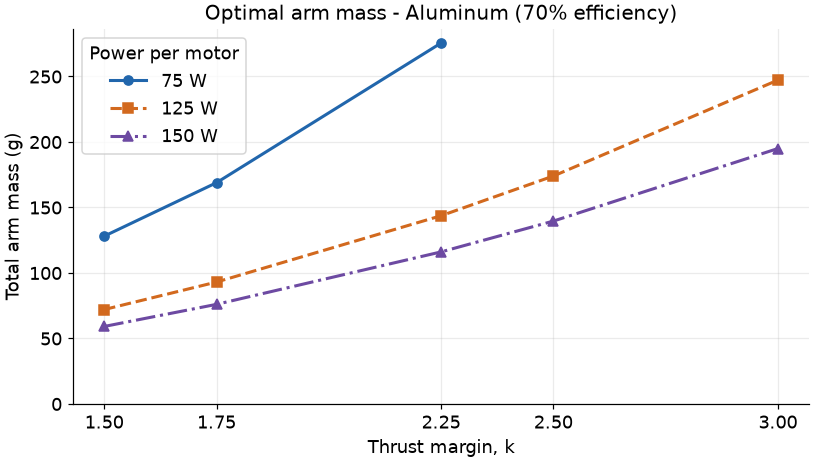

In [7]:
colors  = {75: '#2166AC', 125: '#D2691E', 150: '#6D4AA2'}
markers = {75: 'o', 125: 's', 150: '^'}
lines   = {75: '-', 125: '--', 150: '-.'}

fig, ax = plt.subplots(figsize=(7.4, 4.2), layout='constrained')
for power in powers:
    rows = study[study[:, 0] == power]
    ax.plot(rows[:, 1], rows[:, 4], color=colors[power], marker=markers[power],
            ls=lines[power], lw=2, label=f'{power} W')
ax.set(xlabel='Thrust margin, k', ylabel='Total arm mass (g)', xticks=margins, xlim=(1.43, 3.07))
ax.set_ylim(bottom=0)
ax.set_title('Optimal arm mass - Aluminum (70% efficiency)')
ax.legend(title='Power per motor', loc='upper left')
ax.grid(alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)
plt.show()

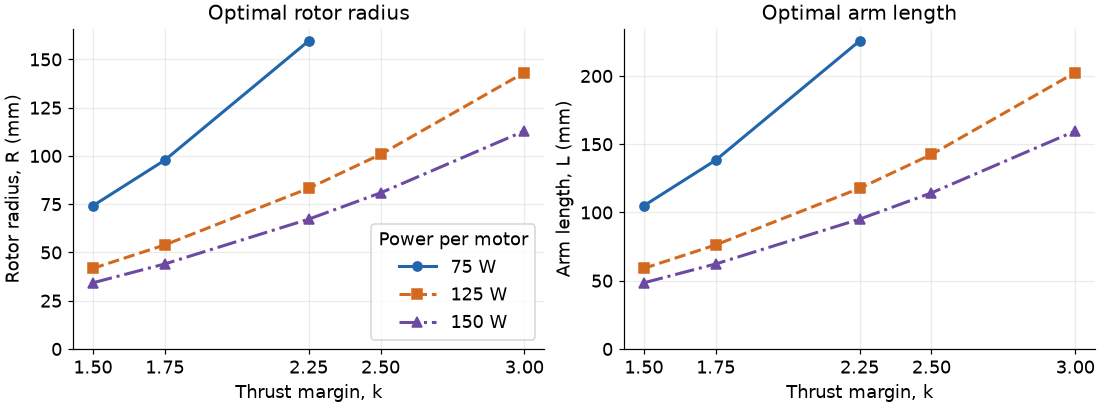

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.7), layout='constrained')

for ax, col, ylabel, title in zip(axes, [2, 3],
                                  ['Rotor radius, R (mm)', 'Arm length, L (mm)'],
                                  ['Optimal rotor radius', 'Optimal arm length']):
    for power in powers:
        rows = study[study[:, 0] == power]
        ax.plot(rows[:, 1], rows[:, col], color=colors[power], marker=markers[power],
                ls=lines[power], lw=2, label=f'{power} W')
    ax.set(xlabel='Thrust margin, k', ylabel=ylabel, xticks=margins, xlim=(1.43, 3.07))
    ax.set_ylim(bottom=0)
    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].legend(title='Power per motor', loc='lower right')
plt.show()

In [9]:
feasible = study[~np.isnan(study[:, 2])]
stress   = sigma_max(feasible[:, 2], feasible[:, 3], feasible[:, 0])
defl     = delta_tip(feasible[:, 2], feasible[:, 3], feasible[:, 0])
i_s, i_d = np.argmax(stress), np.argmax(defl)

print("Largest stress and deflection among feasible optima:")
print(f"  σ_max = {stress[i_s]:.3f} MPa at P0 = {feasible[i_s, 0]:.0f} W, k = {feasible[i_s, 1]:g}  (bound: {sigma_y:.0f} MPa)")
print(f"  δ_tip = {defl[i_d]:.3f} mm  at P0 = {feasible[i_d, 0]:.0f} W, k = {feasible[i_d, 1]:g}  (bound: {delta_max} mm)")

Largest stress and deflection among feasible optima:
  σ_max = 12.705 MPa at P0 = 125 W, k = 3  (bound: 90 MPa)
  δ_tip = 0.444 mm  at P0 = 75 W, k = 2.25  (bound: 0.5 mm)
